# Tutorial 2: NeKo - Advanced Network Construction & Analysis (STUDENT VERSION)

## Learning Objectives
By the end of this tutorial, you will be able to:
1. Connect disconnected nodes using intermediate genes
2. Use different algorithms for network completion
3. Work with custom databases and multiple resources
4. Analyze network topology and identify key features
5. Handle complex biological scenarios with incomplete connectivity

## Introduction
In Tutorial 1, we learned basic network building with direct connections. However, biological networks often require intermediate nodes to connect genes that don't interact directly. This tutorial covers advanced techniques for building comprehensive, biologically meaningful networks.

**Time required:** ~60 minutes

## Before You Start
Make sure you have completed Tutorial 1 and understand basic network construction concepts.

## Section 1: Setup and Review

Let's start by importing the necessary libraries and reviewing basic concepts.

In [3]:
# Import necessary libraries
from neko.core.network import Network
from neko._visual.visualize_network import NetworkVisualizer
import omnipath as op
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## Section 2: The Problem of Disconnected Networks

In real biological scenarios, direct connections between genes of interest might not exist. Consider the following two set of genes:

- Gene set A: SOD1, CAT, GPX1
- Gene set B: TP53, CDKN1A, ATM

Let's see what happens when we try to build a direct network.

In [ ]:
# Define our gene sets
gene_set_A = ['SOD1', 'CAT', 'GPX1']
gene_set_B = ['TP53', 'CDKN1A', 'ATM']
all_genes = gene_set_A + gene_set_B

print("Our genes of interest:")
print(f"Oxidative stress: {gene_set_A}")
print(f"Cell cycle: {gene_set_B}")
print(f"Total genes: {len(all_genes)}")

In [ ]:
# Build a basic network with direct connections only
basic_network = Network(all_genes, resources='omnipath')

# TODO: connect the two sets of genes using the "connect_nodes" method

print(f"Basic network - Nodes: {len(basic_network.nodes)}, Edges: {len(basic_network.edges)}")

### Is the network fully connected?

## Section 3: Connecting Networks with Intermediate Nodes

When direct connections don't exist, we can use intermediate nodes to bridge gaps. NeKo provides several algorithms for this purpose.

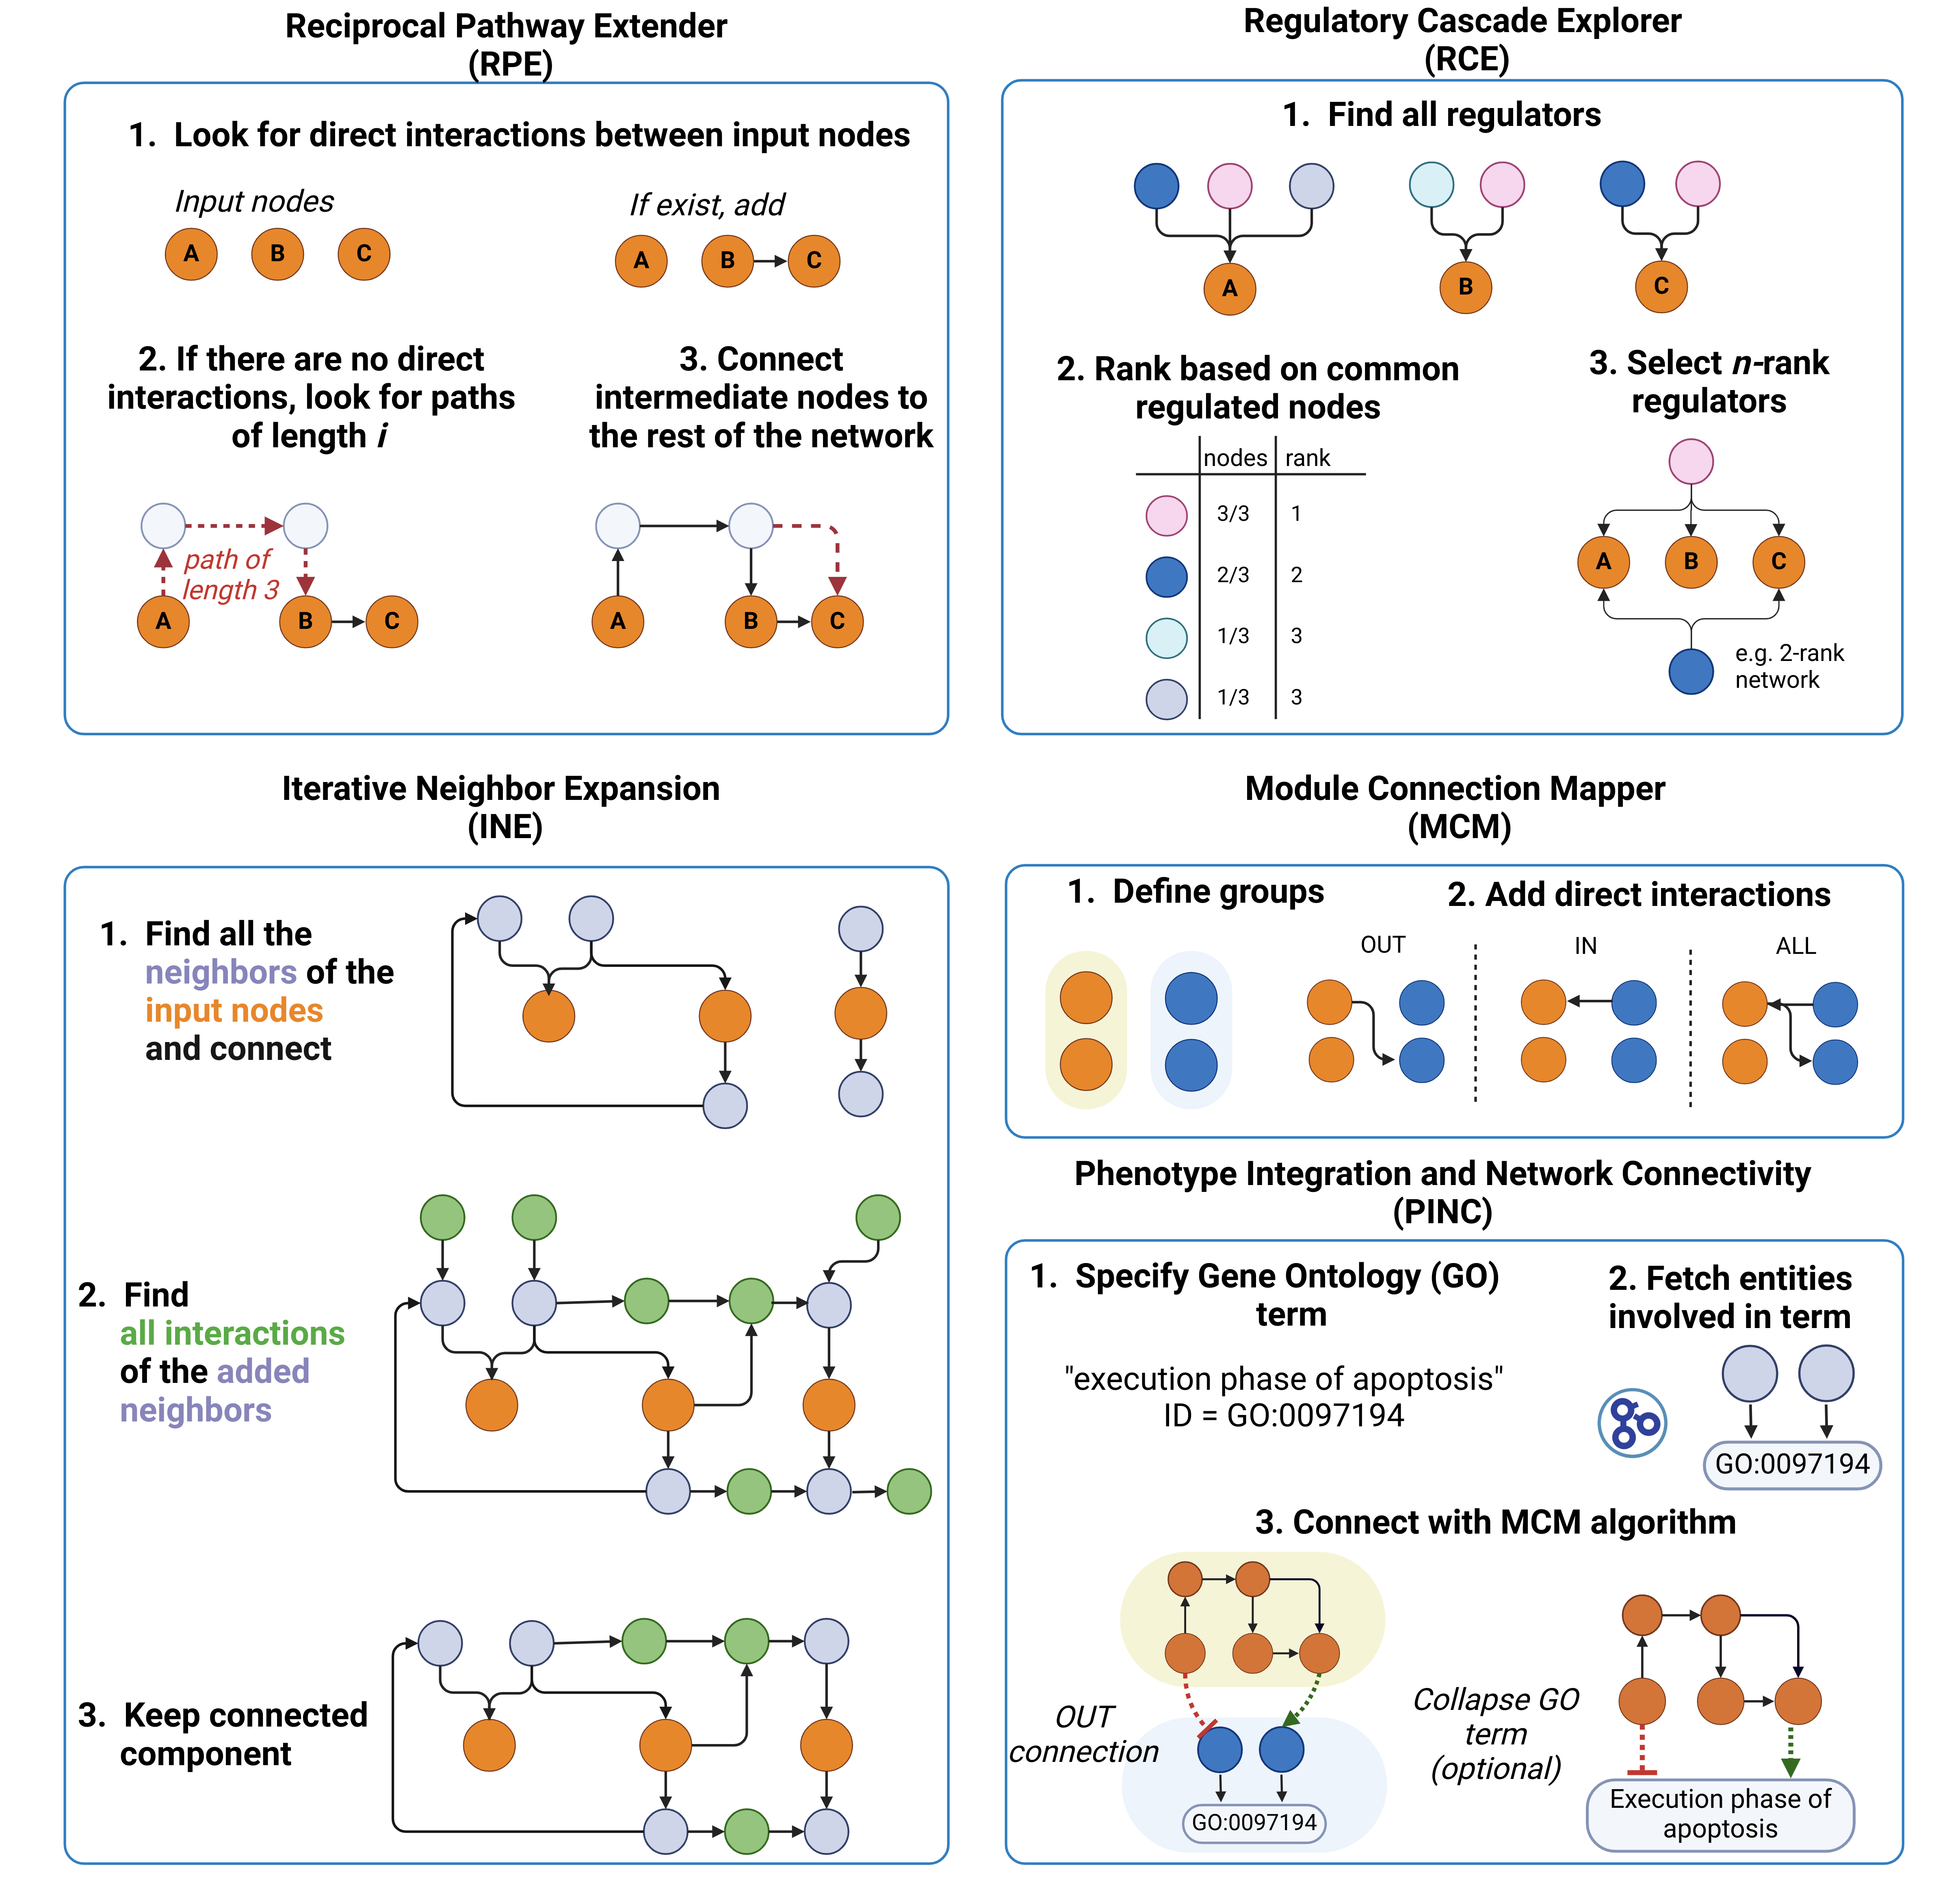

In [2]:
from IPython.display import Image
Image(filename='_static/Strategies_NeKo.png')

### Where to find those strategies? Check out the Network object!

- Network.complete_connection
- Network.connect_subgroup
- Network.connect_to_upstream_nodes
- Network.connect_as_atopo
- Network.connect_network_radially
- Network.connect_component
- Network.connect_genes_to_phenotype

The Network class access the "strategies" module where all the algorithms are stored and accessible.

### Make sure to use python helper function to check the documentation of each function!

In [6]:
from neko.core.strategies import *

In [7]:
?complete_connection

Signature:
complete_connection(
    network,
    maxlen: Optional[int] = 2,
    algorithm: Literal['bfs', 'dfs'] = 'dfs',
    minimal: bool = True,
    only_signed: bool = False,
    consensus: bool = False,
    connect_with_bias: bool = False,
) -> None
Docstring:
Attempts to connect all nodes of a network object using one of the methods presented in the Connection object.
For each node pair, checks for existing paths in both directions using BFS (with sign/consensus as needed).
If a path is missing, calls the selected algorithm to try to find and add a path.
Uses the minimal flag to reset the Connections object as needed.
After all, if connect_with_bias is False, calls connect_nodes and deduplicates edges.
If maxlen=None, performs a single unbounded BFS (no iterative deepening needed).
File:      ~/miniforge3/envs/hands_on/lib/python3.11/site-packages/neko/core/strategies.py
Type:      function

### Exercise: chose the appropriate strategy to connect disconnected nodes in the network

In [ ]:
# TODO: connect all the nodes in the network using the "complete_connection" strategy (for example)

# TODO: Analyze the improvement:
# - How many nodes were added?
# - How many edges were added?
# - Is the network now connected?
# - Which intermediate nodes were most important?

# TODO: Inspect the edges dataframe

### Exercise 3: Compare strategies

**Task:** Create a new network and use a different strategy to connect all the nodes. Is the topology different?

In [ ]:
# TODO: Create a new network object using the same set of genes as above
# - pick a different strategy, e.g., complete_connection using bfs or dfs, or connect network radially

# TODO: Visualize the new network

# TODO: Discussion questions:
# 1. Which strategy added more nodes?
# 2. Which strategy added more edges?

## Section 4: Working with Multiple Databases

By default, the OmniPath database is used with NeKo, but the user can decide to plug into the Network object any database which format resembles OmniPath. Please refer to the Universe class API to check how to adapt a new database to the NeKo standards.

In [ ]:
from neko.inputs import Universe, signor

In [ ]:
# Load the CollecTRI interactions from OmniPath
collectri = op.interactions.CollecTRI.get()
resources = Universe()
resources.add_resources(collectri, name = 'collectri')
resources.build()

In [ ]:
# Download and load the SIGNOR interactions
resources = signor()  # this function accept only tab separated values
resources.build()

In [ ]:
genes = []
signor_network = Network(genes, resources = resources.interactions)

### Exercise: Database Integration Analysis

**Task:** Analyze how different databases contribute to network connectivity.

In [ ]:
# TODO: Build separate networks for each database type
# Create three networks:
# 1. Omnipath network (protein-protein interactions)
# 2. Signor network
# 3. Collectri network

# TODO: Compare the contribution of each database:
# - Number of nodes and edges from each
# - Unique connections provided by each database
# - Overlap between databases

## Section 5: Exporting a network in sif or Bnet format

Once satisfied with the Network topology, we can export the network in Simple Interaction Format or as Bnet file.
When exporting as a bnet, a set of rules is automatically generated for each node to determine its activation.

The generation method is straight forward: give a gene/protein A, its logical rule will be determined by its upstream activators and inhibitors. 

A: (all activators chained by OR gate) AND NOT (all the inhibitors chained by OR gate)

In [ ]:
from neko._outputs.exports import Exports

In [ ]:
exporter = Exports(network)

In [ ]:
exporter.export_bnet("path_to_export")
exporter.export_sif("path_to_export")

# Bonus section: Importing a Network as a sif file

### When creating a network object, instead of a list of genes, you can directly import a network to further analyze it and connect it.

### Exercise: create a new network by importing a sif file generated in the previous section